## 1. 라이브러리 및 환경설정

In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import gradio as gr

sns.set_theme(style="whitegrid", font_scale=1.05)

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")
POWER_KEY = os.getenv("POWER_USAGE_KEY") # 전력사용량 api key

SAVE_DIR = "dataScience/project/data"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"'{SAVE_DIR}' 폴더 준비 완료")

'dataScience/project/data' 폴더 준비 완료


#### 1-1. 임의의 날짜 설정
- api 부하 및 불안정 이슈로 임의로 12개월 선정
- api가 제공하는 데이터가 최소 2개월 이전 데이터인 관계로 3개월 전 데이터 기준 수집

In [2]:
from datetime import date
from dateutil.relativedelta import relativedelta
today = date.today()

# 3개월 전
three_months_ago = today - relativedelta(months=3)

# 3개월 전 달의 마지막 날
end_date = three_months_ago + relativedelta(day=31)

# end_date 기준 1년 전의 다음 달 1일
start_date = end_date - relativedelta(years=1) + relativedelta(months=1, day=1)
start_date = start_date.strftime("%Y-%m-%d")
end_date = end_date.strftime("%Y-%m-%d")
# start_date = '2025-07-01'
# end_date = '2026-06-30'
print(f"기준 12개월 데이터 날짜 범위 : {start_date} ~ {end_date}")

기준 12개월 데이터 날짜 범위 : 2025-07-01 ~ 2026-06-30


## 2. 날씨 데이터 수집

In [3]:
SEOUL_LAT = 37.5665
SEOUL_LON = 126.9780

# 출처 : https://open-meteo.com/en/docs/historical-weather-api?daily=temperature_2m_mean
def fetch_seoul_weather(start, end):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": SEOUL_LAT,
        "longitude": SEOUL_LON,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean",
        "timezone": "Asia/Seoul",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    # print(data)

    weather_df = pd.DataFrame(data["daily"])
    weather_df.columns = ["ORDER_DATE", "최고기온", "최저기온", "평균기온"]
    weather_df["ORDER_DATE"] = pd.to_datetime(weather_df["ORDER_DATE"])

    # 월별 통계로 재구성
    weather_df['년월'] = weather_df['ORDER_DATE'].dt.to_period('M')
    monthly_data = weather_df.groupby('년월')[['최고기온', '최저기온', '평균기온']].mean().round(1).reset_index()
    return monthly_data


weather_df = fetch_seoul_weather(start_date, end_date)
print(f"날씨 데이터 {len(weather_df)}개월치 수집 완료")
weather_df.tail(20)

날씨 데이터 12개월치 수집 완료


,년월,최고기온,최저기온,평균기온
0,2025-07,32.3,24.4,27.8
1,2025-08,30.9,24.0,27.1
2,2025-09,26.2,19.2,22.3
3,2025-10,19.4,12.2,15.5
4,2025-11,12.3,3.1,7.3
5,2025-12,3.4,-4.3,-0.7
6,2026-01,-1.0,-9.3,-5.2
7,2026-02,5.8,-3.8,0.6
8,2026-03,11.8,1.5,6.0
9,2026-04,19.7,8.2,13.5


## 3. 전력 사용량 데이터 수집

In [4]:
import time
SEOUL_METRO_CD = 11
dataset_powerUsage = []

# 출처 : https://bigdata.kepco.co.kr/cmsmain.do?pcode=000493&pstate=house&redirect=Y&scode=S01
def get_seoul_powerUsage(year, month):
    url = "https://bigdata.kepco.co.kr/openapi/v1/powerUsage/houseAve.do"
    params = {
        "year": year,
        "month": month,
        "metroCd": SEOUL_METRO_CD,
        "apiKey": POWER_KEY,
        "returnType": "json"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()["data"]


def fetch_seoul_powerUsage(dataset) :
    power_df = pd.DataFrame(dataset)
    power_df.columns = ["년도", "월", "시도", "시구", "가구수", "전력사용량", "요금"]
    power_df["년월"] = pd.to_datetime(power_df["년도"]+"-"+power_df["월"]).dt.to_period("M")
    power_df = power_df.drop(columns=['년도', '월', '시도'])
    # print(power_df)
    return power_df

def get_power_df() :
    for year_month in weather_df['년월']:
        year, month = str(year_month).split('-')
        dataset_powerUsage.extend(get_seoul_powerUsage(year, month))
        time.sleep(1) # api 오류가 너무 심해서 방지용

    power_df = fetch_seoul_powerUsage(dataset_powerUsage)
    print(f"전력사용량 데이터 {int(len(power_df) / power_df["시구"].nunique())}개월치 수집 완료")
    # power_df.tail(20)
    return power_df

# for year_month in weather_df['년월']:
#     year, month = str(year_month).split('-')
#     dataset_powerUsage.extend(get_seoul_powerUsage(year, month))
#     time.sleep(1) # api 오류가 너무 심해서 방지용

# power_df = fetch_seoul_powerUsage(dataset_powerUsage)
# print(f"전력사용량 데이터 {int(len(power_df) / power_df["시구"].nunique())}개월치 수집 완료")
# power_df.tail(20)

In [11]:
def exists_power_usage (cursor) :
    sql = "select count(*) from user_tables where table_name = 'SEOUL_POWER_USAGE'"
    cursor.execute(sql)
    return cursor.fetchone()[0] > 0

def select_power_usage (cursor) :
    sql = "select district, house_num,power_usage,bill,year_month from seoul_power_usage"
    cursor.execute(sql)
    return cursor.fetchall()

def create_power_usage_table (cursor) :
    sql = """
    CREATE TABLE seoul_power_usage(
        pu_id       NUMBER(10) GENERATED BY DEFAULT AS IDENTITY NOT NULL,
        district    VARCHAR2(20),
        house_num   NUMBER(10)  ,
        power_usage NUMBER(5)   ,
        bill        number(10)  ,
        year_month  DATE        ,
        CONSTRAINT PK_seoul_power_usage PRIMARY KEY (pu_id)
    )"""
    cursor.execute(sql)

def insert_power_usage(df, cursor):

    sql = """
        INSERT INTO seoul_power_usage (
            district,
            house_num,
            power_usage,
            bill,
            year_month
        )
        VALUES (:1,:2,:3,:4,TO_DATE(:5, 'YYYY-MM'))
    """

    data = [(
            row["시구"],
            row["가구수"],
            row["전력사용량"],
            row["요금"],
            row["년월"].strftime("%Y-%m")
        ) for _, row in df.iterrows()]

    cursor.executemany(sql, data)


def process_power_usage() : 
    with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
        with conn.cursor() as cursor:
            try:
                if not exists_power_usage(cursor) :
                    create_power_usage_table(cursor)
                if not select_power_usage(cursor) :
                    power_df = get_power_df()
                    insert_power_usage(power_df, cursor)
                    conn.commit()

                return select_power_usage(cursor)

            except oracledb.DatabaseError as e:
                    return False

sql_data = process_power_usage()

power_df = pd.DataFrame(sql_data,columns=["시구","가구수","전력사용량","요금","년월"] )
power_df["년월"] = pd.to_datetime(power_df["년월"]).dt.to_period("M")
print(f"전력사용량 데이터 {int(len(power_df) / power_df["시구"].nunique())}개월치 수집 완료")
power_df.tail(20)

전력사용량 데이터 12개월치 수집 완료


,시구,가구수,전력사용량,요금,년월
280,금천구,135321,199,27899,2026-06
281,영등포구,221002,217,30657,2026-06
282,송파구,295895,257,37354,2026-06
283,종로구,90097,195,29852,2026-06
284,성동구,145172,242,34197,2026-06
285,마포구,201688,230,33009,2026-06
286,강동구,233666,251,36176,2026-06
287,동대문구,209624,214,29691,2026-06
288,도봉구,152150,221,29103,2026-06
289,은평구,232750,228,31985,2026-06


In [12]:
weather_csv_path = os.path.join(SAVE_DIR, "weather_seoul_monthly.csv")
weather_df.to_csv(weather_csv_path, index=False, encoding="utf-8-sig")
print(f"날씨 데이터 저장 완료 : {weather_csv_path}")

powerUsage_csv_path = os.path.join(SAVE_DIR, "powerUsage_seoul.csv")
power_df.to_csv(powerUsage_csv_path, index=False, encoding="utf-8-sig")
print(f"전력 데이터 저장 완료 : {powerUsage_csv_path}")

날씨 데이터 저장 완료 : dataScience/project/data\weather_seoul_monthly.csv
전력 데이터 저장 완료 : dataScience/project/data\powerUsage_seoul.csv


## 4. 날씨 데이터, 전력 사용량 데이터 결합

In [13]:
merged_df = pd.merge(power_df, weather_df, on="년월", how="left")

print(f"결합된 데이터 : {len(merged_df)}행")
merged_df.head(25)

결합된 데이터 : 300행


,시구,가구수,전력사용량,요금,년월,최고기온,최저기온,평균기온
0,중구,77551,292,46746,2025-07,32.3,24.4,27.8
1,강북구,159018,248,34945,2025-07,32.3,24.4,27.8
2,서초구,190406,373,66653,2025-07,32.3,24.4,27.8
3,종로구,89428,261,42437,2025-07,32.3,24.4,27.8
4,은평구,231308,299,44975,2025-07,32.3,24.4,27.8
5,관악구,306924,224,32010,2025-07,32.3,24.4,27.8
6,강동구,233617,317,48559,2025-07,32.3,24.4,27.8
7,도봉구,151710,286,39375,2025-07,32.3,24.4,27.8
8,금천구,134397,258,37905,2025-07,32.3,24.4,27.8
9,영등포구,219318,287,43822,2025-07,32.3,24.4,27.8


## 5. numpy 분석 + 시각화

In [14]:
weather_power_pivot = pd.pivot_table(
    merged_df, values="전력사용량", index="시구", columns="평균기온",
    aggfunc="mean", fill_value=0,
).round(1)
weather_power_pivot["최고-최저 사용량"] = (
    weather_power_pivot.drop(columns='최고-최저 사용량', errors='ignore').max(axis=1)
    - weather_power_pivot.drop(columns='최고-최저 사용량', errors='ignore').min(axis=1)
)
weather_power_pivot_sorted = weather_power_pivot.sort_values("최고-최저 사용량", ascending=False)

print("=== 기온에 따른 전력 사용량 차이가 큰 시구군 순위 ===")
print(weather_power_pivot_sorted)

=== 기온에 따른 전력 사용량 차이가 큰 시구군 순위 ===
평균기온   -5.2   -0.7    0.6    6.0    7.3   13.5   15.5   18.9   22.3   23.8  \
시구                                                                           
서초구   278.0  256.0  274.0  240.0  245.0  244.0  261.0  234.0  399.0  273.0   
용산구   257.0  231.0  257.0  213.0  218.0  215.0  232.0  203.0  358.0  244.0   
강남구   275.0  253.0  265.0  235.0  240.0  233.0  252.0  229.0  358.0  267.0   
송파구   275.0  249.0  277.0  235.0  241.0  242.0  250.0  226.0  370.0  257.0   
성동구   265.0  236.0  270.0  224.0  227.0  229.0  244.0  211.0  364.0  242.0   
양천구   270.0  246.0  271.0  232.0  238.0  237.0  249.0  222.0  359.0  246.0   
마포구   247.0  222.0  246.0  205.0  211.0  208.0  223.0  196.0  329.0  230.0   
강동구   270.0  245.0  269.0  228.0  235.0  232.0  245.0  221.0  349.0  251.0   
은평구   257.0  232.0  251.0  216.0  220.0  217.0  226.0  206.0  323.0  228.0   
성북구   256.0  230.0  257.0  218.0  222.0  223.0  233.0  207.0  336.0  230.0   
영등포구  232.0  209.0  228.0  19

In [15]:
monthly_avg = (
    merged_df
    .groupby('년월')[['최고기온', '최저기온', '평균기온', '전력사용량']]
    .mean()
    .reset_index()
)

print(monthly_avg)

         년월  최고기온  최저기온  평균기온   전력사용량
0   2025-07  32.3  24.4  27.8  291.92
1   2025-08  30.9  24.0  27.1  368.36
2   2025-09  26.2  19.2  22.3  321.00
3   2025-10  19.4  12.2  15.5  220.28
4   2025-11  12.3   3.1   7.3  210.92
5   2025-12   3.4  -4.3  -0.7  221.08
6   2026-01  -1.0  -9.3  -5.2  244.56
7   2026-02   5.8  -3.8   0.6  243.40
8   2026-03  11.8   1.5   6.0  206.16
9   2026-04  19.7   8.2  13.5  209.24
10  2026-05  24.6  14.2  18.9  197.72
11  2026-06  29.2  19.0  23.8  225.60


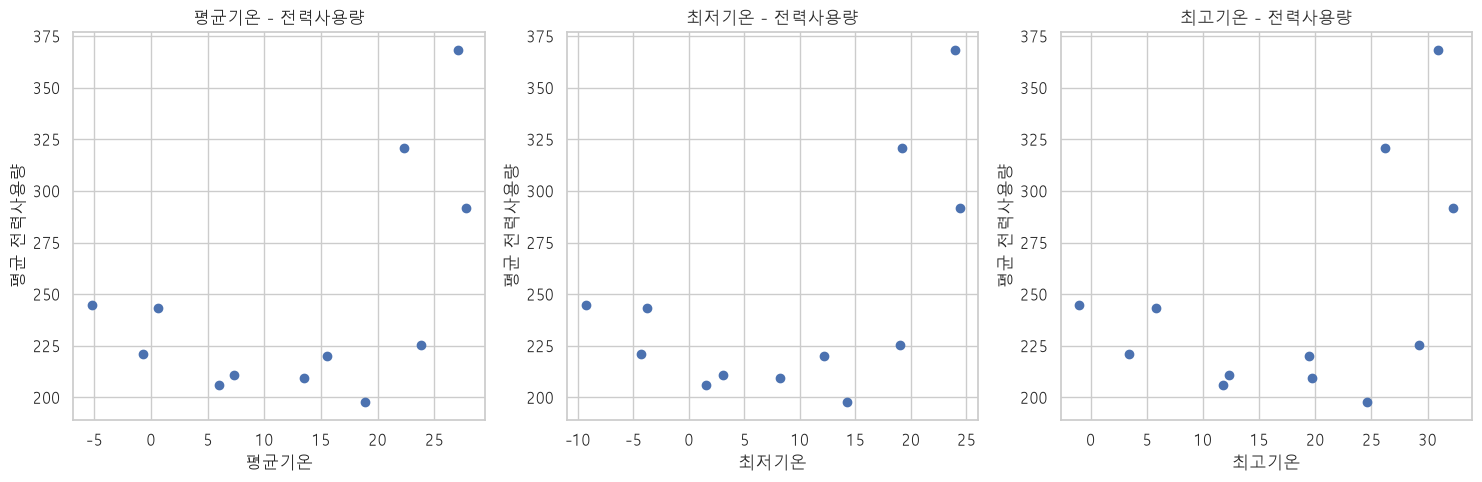

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(
    monthly_avg['평균기온'],
    monthly_avg['전력사용량']
)
axes[0].set_xlabel('평균기온')
axes[0].set_ylabel('평균 전력사용량')
axes[0].set_title('평균기온 - 전력사용량')


axes[1].scatter(
    monthly_avg['최저기온'],
    monthly_avg['전력사용량']
)
axes[1].set_xlabel('최저기온')
axes[1].set_ylabel('평균 전력사용량')
axes[1].set_title('최저기온 - 전력사용량')


axes[2].scatter(
    monthly_avg['최고기온'],
    monthly_avg['전력사용량']
)
axes[2].set_xlabel('최고기온')
axes[2].set_ylabel('평균 전력사용량')
axes[2].set_title('최고기온 - 전력사용량')


# 그래프 간 간격 자동 조정
plt.tight_layout()

plt.show()

- 산점도가 U자형으로 비선형적, 비대칭적 관계이므로 corrcoef 상관계수 분석에 부적절함
- 실습을 위해 평균 전력사용량이 평균기온 기준 최저인 19도를 기준으로 선형이라고 가정

In [17]:
# 평균기온을 기준
pivot_power =pd.pivot_table(
    merged_df,
    values="전력사용량",
    index="시구",
    columns="평균기온",
    aggfunc="mean",
    fill_value=0,
    margins=True, # 총계 행/열 자동으로 추가
    margins_name="전체평균", # 원래 ALL인데 전체평균
)

print(pivot_power.round(0))

평균기온   -5.2   -0.7    0.6    6.0    7.3   13.5   15.5   18.9   22.3   23.8  \
시구                                                                           
강남구   275.0  253.0  265.0  235.0  240.0  233.0  252.0  229.0  358.0  267.0   
강동구   270.0  245.0  269.0  228.0  235.0  232.0  245.0  221.0  349.0  251.0   
강북구   224.0  201.0  228.0  189.0  193.0  193.0  198.0  179.0  288.0  199.0   
강서구   232.0  212.0  233.0  199.0  205.0  203.0  217.0  191.0  317.0  214.0   
관악구   190.0  171.0  191.0  158.0  165.0  163.0  174.0  153.0  254.0  178.0   
광진구   220.0  198.0  219.0  182.0  189.0  187.0  199.0  177.0  300.0  209.0   
구로구   242.0  220.0  241.0  206.0  209.0  208.0  217.0  197.0  314.0  221.0   
금천구   216.0  196.0  214.0  182.0  188.0  185.0  197.0  176.0  282.0  199.0   
노원구   265.0  240.0  262.0  221.0  228.0  224.0  223.0  209.0  311.0  232.0   
도봉구   251.0  228.0  250.0  211.0  217.0  213.0  215.0  200.0  302.0  221.0   
동대문구  225.0  202.0  229.0  194.0  195.0  200.0  211.0  188.0  31

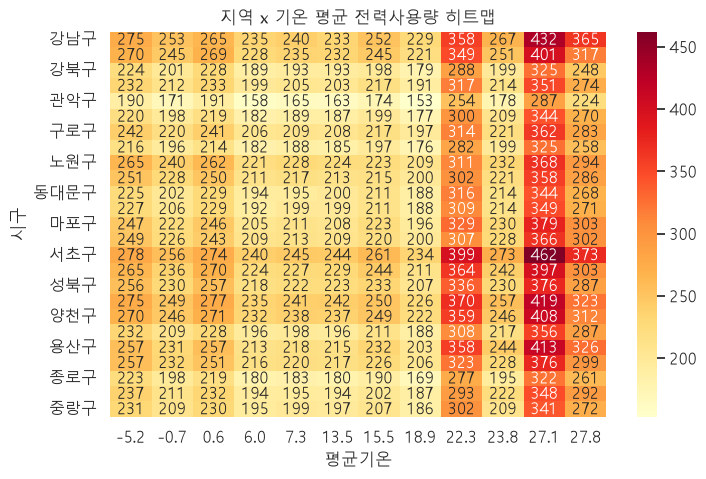

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot_power.drop("전체평균",axis=0).drop("전체평균",axis=1),annot=True,fmt=".0f",cmap="YlOrRd")
plt.title("지역 x 기온 평균 전력사용량 히트맵")
plt.show()

In [19]:
# 실습을 위해 평균 전력사용량이 평균기온 기준 최저인 18.9도를 기준으로 양측 선형이라고 가정

lower_df = merged_df[merged_df['평균기온'] <= 18.8]
upper_df = merged_df[merged_df['평균기온'] > 18.8]

lower_total = lower_df.groupby("년월").agg(
    전력사용량=("전력사용량", "mean"),
    평균기온=("평균기온", "mean"),
).reset_index()

corr_matrix_lower = np.corrcoef(lower_total["전력사용량"], lower_total["평균기온"])
corr_value_lower = corr_matrix_lower[0, 1]
print(f"(평년 이하)평균기온-평균 전력사용량 상관계수 : {corr_value_lower:.3f}")
if corr_value_lower > 0.3:
    print("-> 평년이하 기온에서 기온이 떨어질수록 전력 사용량이 감소합니다.")
elif corr_value_lower < -0.3:
    print("-> 평년이하 기온에서 기온이 떨어질수록 전력 사용량이 증가합니다.")
else:
    print("-> 평년이하 기온에서는 기온과 전력 사용량은 별 관계가 없습니다.")


upper_total = upper_df.groupby("년월").agg(
    전력사용량=("전력사용량", "mean"),
    평균기온=("평균기온", "mean"),
).reset_index()

corr_matrix_upper = np.corrcoef(upper_total["전력사용량"], upper_total["평균기온"])
corr_value_upper = corr_matrix_upper[0, 1]
print(f"(평년 이상)평균기온-평균 전력사용량 상관계수 : {corr_value_upper:.3f}")
if corr_value_upper > 0.3:
    print("-> 평년이상 기온에서 기온이 높아질수록 전력 사용량이 증가합니다.")
elif corr_value_upper < -0.3:
    print("-> 평년이상 기온에서 기온이 높아질수록 전력 사용량이 감소합니다.")
else:
    print("-> 평년이상 기온에서는 기온과 전력 사용량은 별 관계가 없습니다.")

(평년 이하)평균기온-평균 전력사용량 상관계수 : -0.677
-> 평년이하 기온에서 기온이 떨어질수록 전력 사용량이 증가합니다.
(평년 이상)평균기온-평균 전력사용량 상관계수 : 0.672
-> 평년이상 기온에서 기온이 높아질수록 전력 사용량이 증가합니다.


## 6. 분석 결과 파일 저장

In [20]:
merged_csv_path = os.path.join(SAVE_DIR, "merged_weather_powers.csv")
merged_df.to_csv(merged_csv_path, index=False, encoding="utf-8-sig")

summary_csv_path = os.path.join(SAVE_DIR, "weather_powers_summary.csv")
weather_power_pivot_sorted.to_csv(summary_csv_path, encoding="utf-8-sig")

print(f"결합 데이터 저장 완료 : {merged_csv_path}")
print(f"요약 분석 저장 완료   : {summary_csv_path}")

결합 데이터 저장 완료 : dataScience/project/data\merged_weather_powers.csv
요약 분석 저장 완료   : dataScience/project/data\weather_powers_summary.csv


## 7. Gradio 대시보드

In [21]:
# ─────────────────────────────────────────────────────────
# 커스텀 CSS : 전체적으로 글자 크기를 키우고, 카드 모서리를 둥글게,
#              버튼과 입력창에 그림자를 넣어 화면을 화사하게 만듭니다.
# ─────────────────────────────────────────────────────────
custom_css = """
.gradio-container {
    font-size: 16px !important;
}
#title-banner {
    background: linear-gradient(135deg, #FF9A5A 0%, #FF6F91 50%, #4DABF7 100%);
    padding: 28px 24px;
    border-radius: 18px;
    text-align: center;
    margin-bottom: 20px;
    box-shadow: 0 8px 20px rgba(0,0,0,0.12);
}
#title-banner h1 {
    color: white !important;
    font-size: 30px !important;
    margin: 0 0 6px 0 !important;
}
#title-banner p {
    color: white !important;
    font-size: 15px !important;
    opacity: 0.95;
    margin: 0 !important;
}
.gr-button {
    font-size: 16px !important;
    font-weight: 600 !important;
    border-radius: 12px !important;
    padding: 10px 22px !important;
    box-shadow: 0 3px 8px rgba(0,0,0,0.15) !important;
}
label {
    font-size: 15px !important;
    font-weight: 600 !important;
}
.gr-box, .gr-panel, .gr-form {
    border-radius: 14px !important;
}
"""

# ─────────────────────────────────────────────────────────
# 테마 : Soft 테마 + 주황/파랑 계열 색상 지정
# ─────────────────────────────────────────────────────────
custom_theme = gr.themes.Soft(
    primary_hue="orange",
    secondary_hue="blue",
    radius_size="lg",
)

In [22]:
# 탭1 : 날짜별 상세 조회 함수
def show_daily_detail(selected_loc):
    day_data = merged_df[merged_df["시구"] == selected_loc]

    if len(day_data) == 0:
        return "해당 시구의 데이터가 없습니다.", None

    weather_emoji = "⚡️"
    info_text = (
        f"📅 {selected_loc}\n"
        f"🌡️ 최고 {day_data['최고기온'].max():.1f}°C / 최저 {day_data['최저기온'].min():.1f}°C/ 평균 {day_data['평균기온'].mean():.1f}°C\n"
        f"{weather_emoji} 전력사용량 {day_data['전력사용량'].mean():.1f}Kwh "
    )

    day_data_sorted = day_data.sort_values("년월", ascending=True)
    day_data_sorted["년월"] = (
        day_data_sorted["년월"]
        .astype(str)
    )
    colors = "#4DABF7"

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bars = ax.plot(day_data_sorted["년월"], day_data_sorted["전력사용량"],
                   color=colors, marker="o", linewidth=1.5)
    ax.set_title(f"{selected_loc} 연간 평균 전력사용량", fontsize=14, fontweight="bold")
    ax.set_ylabel("전력사용량", fontsize=11)
    plt.xticks(rotation=45)
    sns.despine()
    plt.tight_layout()

    return info_text, fig


# 탭2 : 비/맑음 비교 함수 (Part5 그래프 재사용)
def show_weather_comparison():
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.heatmap(
        pivot_power
            .drop("전체평균", axis=0)
            .drop("전체평균", axis=1),
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        ax=ax
    )

    ax.set_title("지역 x 기온 평균 전력사용량 히트맵")

    plt.tight_layout()
    return fig

In [23]:
available_loc = sorted(merged_df["시구"].unique().tolist())

with gr.Blocks(title="서울 지역별 기온-전력사용량 분석기") as demo:

    # 상단 그라데이션 배너
    gr.HTML(
        """
        <div id="title-banner">
            <h1>⚡️ 서울 기온-전력사용량 분석기</h1>
            <p>Chapter01~03 종합 복습 프로젝트 · 기온에 따라 전력을 얼마나 사용할까요?</p>
        </div>
        """
    )

    with gr.Tab("🌏 지역별 상세 조회"):
        with gr.Row():
            date_dropdown = gr.Dropdown(available_loc, label="시군구 선택", scale=3)
            search_btn = gr.Button("🔍 조회하기", variant="primary", scale=1)
        with gr.Row():
            info_output = gr.Textbox(label="지역 정보", lines=3)
            chart_output = gr.Plot(label="연 평균 전력사용량 통계")

        search_btn.click(
            fn=show_daily_detail,
            inputs=date_dropdown,
            outputs=[info_output, chart_output],
        )

    with gr.Tab("⚡️ 지역별 전력사용량 한 눈에 비교"):
        gr.Markdown("### 지역에 따라 날씨별 전력사용량이 어떻게 달라지는지 비교해보세요.")
        compare_btn = gr.Button("📊 비교 그래프 보기", variant="primary")
        compare_output = gr.Plot(label="기온별 전력사용량")

        compare_btn.click(
            fn=show_weather_comparison,
            inputs=None,
            outputs=compare_output,
        )


# ⚠️ Gradio 6.0부터 theme/css는 gr.Blocks()가 아니라 launch()에 전달합니다.
demo.launch(theme=custom_theme, css=custom_css)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
# demo.close()

Closing server running on port: 7860
